In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")

C:\Users\nbe\AppData\Local\Temp\ipykernel_16992\2627409203.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")


In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["TotalClaims", "TotalPremium"])

In [11]:
df_model = df[df["TotalClaims"] > 0]

In [17]:
features = [
    "TotalPremium",
    "CustomValueEstimate",
    "CapitalOutstanding"
]

df_model = df[df["TotalClaims"] > 0].copy()

# IMPORTANT CLEAN STEP
df_model = df_model[features + ["TotalClaims"]]
df_model = df_model.dropna()

In [18]:
X = df_model[features]
y = df_model["TotalClaims"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.isna().sum())

TotalPremium           0
CustomValueEstimate    0
CapitalOutstanding     0
dtype: int64


In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [22]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 42639.160431154625
Linear Regression R2: 0.2295524216077217


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 46099.50210749784
Random Forest R2: 0.09942834308618964


In [28]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,RMSE,R2
0,Linear Regression,42639.160431,0.229552
1,Random Forest,46099.502107,0.099428


In [29]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,TotalPremium,0.539523
1,CustomValueEstimate,0.331241
2,CapitalOutstanding,0.129236


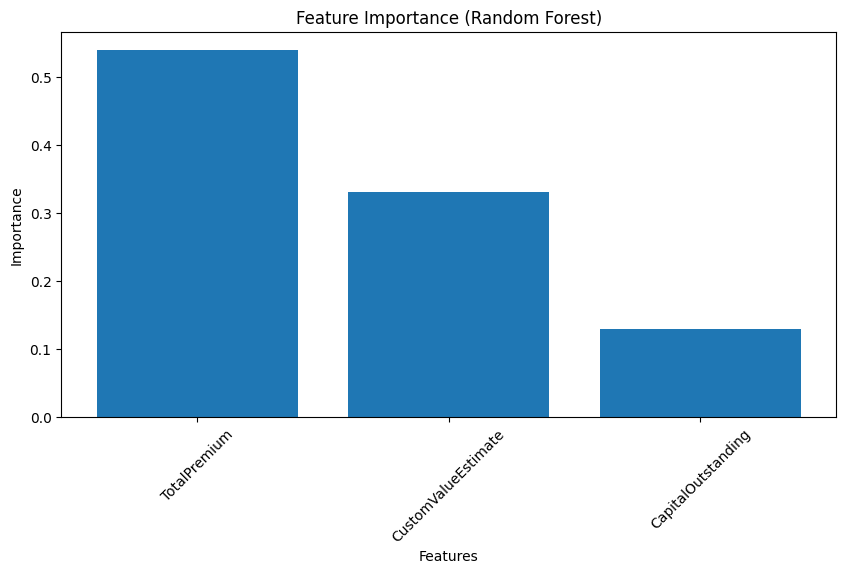

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()


### BUSINESS INTERPRETATION:

The model shows which factors most influence claim severity.

- Features with higher importance are the main drivers of risk.
- These variables should directly influence pricing adjustments.
- Low importance features may be removed to simplify the pricing model.

This helps transform the model from a prediction tool into a pricing strategy engine.
